# 03 · U-Net

Dans le notebook précédent, on a vu qu'une couche de convolution produit des cartes de caractéristiques, et que plus on descend dans le réseau, plus les cartes sont petites et abstraites.

C'est bien pour dire *ce qu'il y a* dans l'image. Mais pour segmenter, il faut dire *où* se trouve chaque chose, pixel par pixel. Il faut donc une sortie qui a la même taille que l'image d'entrée.

U-Net règle ce problème en deux temps :
- une partie qui descend (l'encodeur) : l'image rétrécit, le nombre de canaux augmente, comme dans YOLO ;
- une partie qui remonte (le décodeur) : on agrandit à nouveau jusqu'à retrouver la taille de départ.

Entre les deux, des **skip connections** recopient les cartes de l'encodeur directement dans le décodeur. On va construire le réseau, l'entraîner sur des photos de chiens et de chats, puis voir ce qui se passe quand on enlève ces skip connections.

On commence par les imports.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time

from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

## 1. La brique de base : DoubleConv

Tout le U-Net est construit à partir d'un même petit bloc : deux convolutions 3×3 à la suite, chacune suivie d'une BatchNorm et d'un ReLU.

Avec `padding=1`, la taille de l'image ne change pas. Seul le nombre de canaux change (ici on passe de 3 à 32). La BatchNorm remet les valeurs à une échelle raisonnable, ce qui rend l'entraînement plus stable. On met `bias=False` parce que la BatchNorm a déjà son propre décalage, le biais de la convolution ne servirait à rien.

Le petit test en bas vérifie juste que la forme de sortie est la bonne.

In [2]:

class DoubleConv(nn.Module):
    """(conv 3x3 -> BatchNorm -> ReLU) x 2. Change les canaux, garde la taille."""

    def __init__(self, c_in, c_out):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1, bias=False)
        self.batch1 = nn.BatchNorm2d(c_out)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1, bias=False)
        self.batch2 = nn.BatchNorm2d(c_out)
        self.relu2 = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)
        x = self.batch2(x)
        x = self.relu2(x)
        
        return x


if __name__ == "__main__":
    bloc = DoubleConv(3, 32)
    x = torch.randn(2, 3, 128, 128)          # (batch, canaux, H, W)
    y = bloc(x)
    print("sortie :", tuple(y.shape))
    assert y.shape == (2, 32, 128, 128), "la forme devrait être (2, 32, 128, 128)"

    n = sum(p.numel() for p in bloc.parameters())
    print("paramètres :", n)

sortie : (2, 32, 128, 128)
paramètres : 10208


## 2. Descendre, remonter, et le réseau complet

**Down** : un max-pooling 2×2 divise la taille par 2, puis une DoubleConv augmente le nombre de canaux.

**Up** : une convolution transposée (`ConvTranspose2d`) fait l'inverse, elle double la taille et divise les canaux par 2. Ensuite, si les skip connections sont activées, on colle à côté (`torch.cat`) la carte de l'encodeur qui avait la même taille. C'est pour ça que la DoubleConv qui suit reçoit `c_in` canaux au lieu de `c_in // 2`.

**MiniUNet** : 4 descentes, 4 remontées. Avec `base=32`, les canaux font 32 → 64 → 128 → 256 → 512 en descendant, puis l'inverse en remontant. À la fin, une convolution 1×1 donne un score par classe pour chaque pixel.

Pourquoi les skip connections ? En bas du réseau, l'image ne fait plus que 8×8. Le réseau sait qu'il y a un chat, mais il a perdu les détails des contours. Les skip connections lui redonnent ces détails au moment où il remonte.

Le paramètre `skip` permet de construire les deux versions du réseau pour les comparer plus loin.

In [3]:
class Down(nn.Module):
    """max-pool 2x2 puis DoubleConv : taille / 2, canaux c_in -> c_out"""
    def __init__(self, c_in, c_out):
        super().__init__()
        self.max_pool = nn.MaxPool2d(kernel_size=2) 
        self.doubleConv = DoubleConv(c_in , c_out)

    def forward(self, x):
        x = self.max_pool(x)
        x = self.doubleConv(x)
        return x


class Up(nn.Module):
    """up-conv 2x2 (canaux / 2, taille x 2), concat avec le skip, puis DoubleConv"""
    def __init__(self, c_in, c_out, skip=True):
        super().__init__()
        self.skip = skip
        self.up = nn.ConvTranspose2d(c_in , c_in//2 , kernel_size=2 , stride=2  )
        channel_in = c_in if self.skip else c_in // 2
        self.conv = DoubleConv(channel_in, c_out)
   

    def forward(self, x, skip_connection):
        x = self.up(x)
        if self.skip:
            x = torch.cat((x, skip_connection) , 1) 
            
        x = self.conv(x)
        return x 
        


class MiniUNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=1, base=32, skip=True):
        super().__init__()
        
        # Encodeur :  3 -> 32 -> 64 -> 128 -> 256, bottleneck : 512
        self.inc   = DoubleConv(in_channels, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base*2, base * 4)
        self.down3 = Down(base*4, base * 8)
        self.down4 = Down(base*8, base * 16)
        
        # Décodeur up1 (512 -> 256), up2, up3, up4 (64 -> 32)
        self.up1 = Up(base*16 , base*8, skip)
        self.up2 = Up(base*8 , base*4 , skip)
        self.up3 = Up(base*4 , base*2, skip)
        self.up4 = Up(base*2 , base, skip)
        
        # Sortie : conv 1x1 de base vers n_classes
        self.outc = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)       
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x,x3 )
        x = self.up3(x,x2)
        x = self.up4(x,x1)
        
        return self.outc(x)
        
          
if __name__ == "__main__":
    model = MiniUNet(in_channels=3, n_classes=1)
    model_2 = MiniUNet(in_channels=3, n_classes=1 , skip=False)
    x = torch.randn(2, 3, 128, 128)
    y = model(x)
    print("sortie :", tuple(y.shape))
    assert y.shape == (2, 1, 128, 128)

    n = sum(p.numel() for p in model.parameters())
    print(f"paramètres : {n:,}")
    assert n == 7_763_041, "nombre de paramètres inattendu"
    
    n = sum(p.numel() for p in model_2.parameters())
    print(f"paramètres pour le model sans les skip connections : {n:,}")
    assert n == 6_979_681, "nombre de paramètres inattendu"

sortie : (2, 1, 128, 128)
paramètres : 7,763,041
paramètres pour le model sans les skip connections : 6,979,681


Où sont les paramètres ? On regarde bloc par bloc. La plus grosse partie est en bas du réseau, là où il y a le plus de canaux.

In [7]:
# total
print(sum(p.numel() for p in model.parameters()))

# détail par bloc
for nom, bloc in model.named_children():
    print(f"{nom:6s} {sum(p.numel() for p in bloc.parameters()):>12,}")

7763041
inc          10,208
down1        55,552
down2       221,696
down3       885,760
down4     3,540,992
up1       2,295,040
up2         574,080
up3         143,680
up4          36,000
outc             33


## 3. Les données : Oxford-IIIT Pet

C'est un jeu de données d'environ 7 000 photos de chiens et de chats, avec un masque pour chaque photo. Dans le masque, chaque pixel vaut 1 (animal), 2 (fond) ou 3 (bordure, la zone floue autour de l'animal). On retire 1 pour avoir des classes 0, 1, 2, c'est ce que PyTorch attend.

Deux points importants dans `transform_paire` :
- l'image et le masque doivent subir exactement le même redimensionnement, sinon ils ne correspondent plus ;
- pour le masque, on utilise l'interpolation `NEAREST`. Avec une interpolation bilinéaire, un pixel entre la classe 0 et la classe 2 pourrait devenir 1, ce qui n'a aucun sens.

On garde 500 images du `trainval` pour la validation. Le `test` ne sert qu'à la toute fin.

In [4]:
TAILLE = 128
MEAN = [0.485, 0.456, 0.406]   # moyenne et écart-type ImageNet, un standard
STD = [0.229, 0.224, 0.225]
CLASSES = ["animal", "fond", "bordure"]


def transform_paire(image, masque):
    """Transforme l'image ET son masque ensemble."""
    # Image : interpolation bilinéaire (lisse)
    image = TF.resize(image, [TAILLE, TAILLE], interpolation=InterpolationMode.BILINEAR)
    image = TF.to_tensor(image)                 # (3, H, W), float dans [0, 1]
    image = TF.normalize(image, MEAN, STD)

    # Masque : interpolation NEAREST ( pour avoir toujours des classes entières et pas des valuers flottantes)
    masque = TF.resize(masque, [TAILLE, TAILLE], interpolation=InterpolationMode.NEAREST)
    masque = torch.as_tensor(np.array(masque), dtype=torch.long) - 1   # (H, W), valeurs 0, 1, 2
    return image, masque


def charger_donnees(root="../../data", batch_size=16, n_val=500, seed=42):
    trainval = datasets.OxfordIIITPet(root=root, split="trainval", target_types="segmentation", transforms=transform_paire, download=True)
    test = datasets.OxfordIIITPet(root=root, split="test", target_types="segmentation",transforms=transform_paire, download=True)

    # On sépare trainval en train / validation, avec une graine fixe pour pouvoir reproduire
    g = torch.Generator().manual_seed(seed)
    train, val = random_split(trainval, [len(trainval) - n_val, n_val], generator=g)

    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

Le premier lancement télécharge le jeu de données (environ 800 Mo) dans `data/`.

In [5]:
train_loader, val_loader, test_loader = charger_donnees()

Avant d'entraîner quoi que ce soit, on regarde les données. On vérifie les formes, les valeurs du masque, et la part de chaque classe. Le fond prend plus de la moitié des pixels : un modèle qui répondrait « fond » partout aurait déjà plus de 50 % de bonnes réponses. C'est pour ça qu'on ne se fiera pas à la précision seule.

train : 3180  val : 500  test : 3669
images : (16, 3, 128, 128) torch.float32
masques : (16, 128, 128) torch.int64
valeurs du masque : [0, 1, 2]
  animal   31.5%
  fond     56.5%
  bordure  12.0%


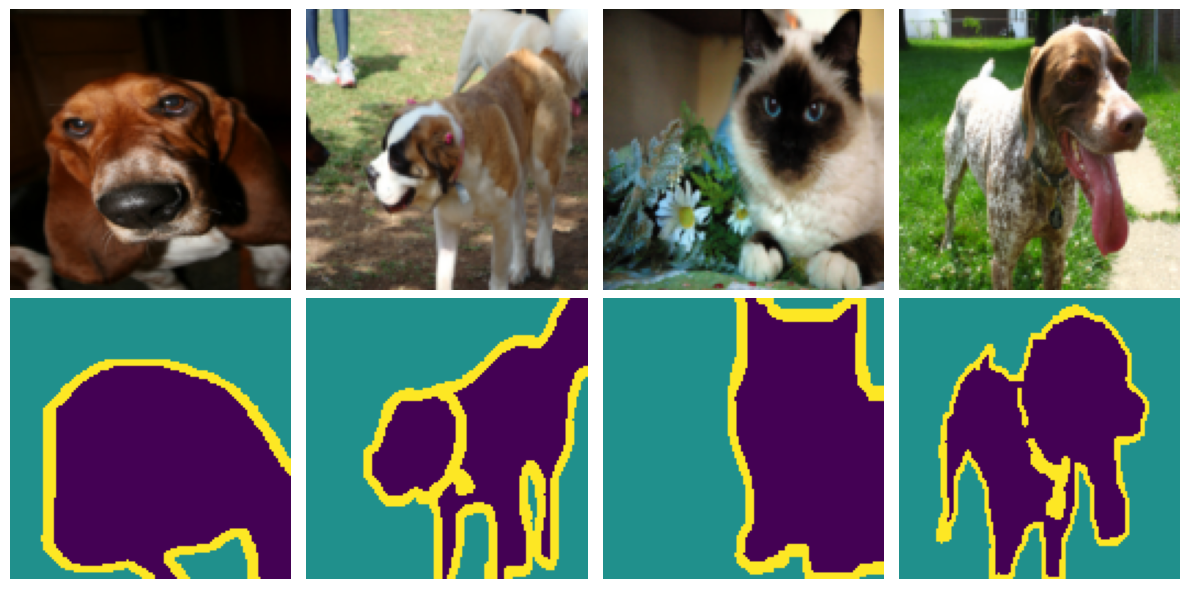

In [6]:
print("train :", len(train_loader.dataset), " val :", len(val_loader.dataset), " test :", len(test_loader.dataset))

# a) Formes, types et valeurs
images, masques = next(iter(train_loader))
print("images :", tuple(images.shape), images.dtype)
print("masques :", tuple(masques.shape), masques.dtype)
print("valeurs du masque :", torch.unique(masques).tolist())

# b) Proportion de chaque classe (utile pour la loss)
for c, nom in enumerate(CLASSES):
    print(f"  {nom:8s} {(masques == c).float().mean():.1%}")

# c) Regarder les images avec leurs masques
def denormaliser(img):
    return (img * torch.tensor(STD)[:, None, None] + torch.tensor(MEAN)[:, None, None]).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for k in range(4):
    axes[0, k].imshow(denormaliser(images[k]).permute(1, 2, 0))   # (C,H,W) -> (H,W,C) pour matplotlib
    axes[1, k].imshow(masques[k], vmin=0, vmax=2)
    axes[0, k].axis("off"); axes[1, k].axis("off")
plt.tight_layout(); plt.show()

## 4. Test de sur-apprentissage

Un réflexe utile avant un long entraînement : on prend un seul batch de 8 images et on demande au réseau de l'apprendre par cœur.

Si tout est bien branché, la loss doit descendre presque à zéro. Si elle ne bouge pas, il y a un bug quelque part (mauvaise forme, mauvaise loss, masque décalé…), et ça ne sert à rien de lancer 15 époques.

On utilise `CrossEntropyLoss` parce qu'on a 3 classes : pour chaque pixel, le réseau donne 3 scores et la loss compare ça à la bonne classe.

In [9]:
# Test overfitting

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", device)

# Un seul batch, toujours le même
train_loader, _, _ = charger_donnees(batch_size=8)
images, masques = next(iter(train_loader))
images, masques = images.to(device), masques.to(device)

model = MiniUNet(in_channels=3, n_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for it in range(201):
    
    logits = model(images)
    loss = criterion(logits , masques)
    
    optimiseur.zero_grad()
    loss.backward()
    optimiseur.step()
    
    
        

    if it % 20 == 0:
        with torch.no_grad():
            pred = logits.argmax(dim=1)                 # (8, 128, 128) : classe prédite par pixel
            acc = (pred == masques).float().mean()
        print(f"it {it:3d}   loss {loss.item():.4f}   précision pixels {acc:.1%}")

device : cuda
it   0   loss 1.0349   précision pixels 40.7%
it  20   loss 0.3408   précision pixels 92.0%
it  40   loss 0.1911   précision pixels 96.4%
it  60   loss 0.1184   précision pixels 98.1%
it  80   loss 0.0781   précision pixels 98.9%
it 100   loss 0.0573   précision pixels 99.3%
it 120   loss 0.0503   précision pixels 99.0%
it 140   loss 0.0333   précision pixels 99.7%
it 160   loss 0.0271   précision pixels 99.8%
it 180   loss 0.0217   précision pixels 99.9%
it 200   loss 0.0176   précision pixels 100.0%


Même test, sans les skip connections. Compare la vitesse à laquelle la loss descend.

In [10]:
# Test overfitting

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", device)

# Un seul batch, toujours le même
train_loader, _, _ = charger_donnees(batch_size=8)
images, masques = next(iter(train_loader))
images, masques = images.to(device), masques.to(device)

model = MiniUNet(in_channels=3, n_classes=3, skip=False).to(device)
criterion = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for it in range(201):
    
    logits = model(images)
    loss = criterion(logits , masques)
    
    optimiseur.zero_grad()
    loss.backward()
    optimiseur.step()
    
    
        

    if it % 20 == 0:
        with torch.no_grad():
            pred = logits.argmax(dim=1)                 # (8, 128, 128) : classe prédite par pixel
            acc = (pred == masques).float().mean()
        print(f"it {it:3d}   loss {loss.item():.4f}   précision pixels {acc:.1%}")

device : cuda
it   0   loss 1.0112   précision pixels 53.6%
it  20   loss 0.4789   précision pixels 85.8%
it  40   loss 0.3003   précision pixels 90.7%
it  60   loss 0.2192   précision pixels 93.1%
it  80   loss 0.1439   précision pixels 96.1%
it 100   loss 0.1131   précision pixels 96.7%
it 120   loss 0.0785   précision pixels 97.8%
it 140   loss 0.0455   précision pixels 99.3%
it 160   loss 0.0352   précision pixels 99.5%
it 180   loss 0.0324   précision pixels 99.3%
it 200   loss 0.0213   précision pixels 99.9%


## 5. Entraînement complet

`train_epoch` fait un passage sur toutes les images d'entraînement. `evaluate` calcule la loss sur la validation, et surtout l'**IoU** de chaque classe.

L'IoU (*Intersection over Union*) mesure à quel point le masque prédit recouvre le vrai masque : on divise les pixels où les deux sont d'accord par tous les pixels où au moins l'un des deux voit la classe. 1 veut dire parfait, 0 veut dire raté. La **mIoU** est la moyenne sur les 3 classes. Contrairement à la précision, elle ne se laisse pas tromper par le fond qui prend toute la place.

À chaque époque, si la mIoU est meilleure que la précédente, on sauvegarde le modèle dans `models/`.

Attention : 15 époques prennent du temps, surtout sans GPU. Les modèles déjà entraînés sont dans `models/`, tu peux sauter directement à la partie 6.

In [11]:
def train_epoch(model, loader, critere, optimiseur, device):
    model.train()
    total, n = 0.0, 0
    for images, masques in loader:
        images, masques = images.to(device), masques.to(device)
        logits = model(images)
        loss = critere(logits, masques)
        optimiseur.zero_grad()
        loss.backward()
        optimiseur.step()
        total += loss.item() * images.size(0)
        n += images.size(0)
    return total / n


@torch.no_grad()                     
def evaluate(model, loader, critere, device, n_classes=3):
    model.eval()                      
    total, n = 0.0, 0
    intersection = torch.zeros(n_classes)
    union = torch.zeros(n_classes)
    for images, masques in loader:
        images, masques = images.to(device), masques.to(device)
        logits = model(images)
        total += critere(logits, masques).item() * images.size(0)
        n += images.size(0)
        pred = logits.argmax(dim=1)

        for c in range(n_classes):
          
            mask_pred = pred == c
            mask_true = masques == c
            
            intersection[c] += (mask_true & mask_pred).sum().item()
            union[c] += (mask_pred | mask_true).sum().item()

    iou = intersection / union.clamp(min=1)    
    return total / n, iou


if __name__ == "__main__":
    
    # Entrainement sur le dataset avec les skip connections
    
    torch.manual_seed(0)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device :", device)
    N_EPOQUES = 15

    train_loader, val_loader, _ = charger_donnees(batch_size=16)   # le test ne sert qu'à la toute fin
    model = MiniUNet(in_channels=3, n_classes=3).to(device)
    critere = nn.CrossEntropyLoss()
    optimiseur = torch.optim.Adam(model.parameters(), lr=1e-3)

    meilleur = 0.0
    for ep in range(1, N_EPOQUES + 1):
        t0 = time.time()
        loss_train = train_epoch(model, train_loader, critere, optimiseur, device)
        loss_val, iou = evaluate(model, val_loader, critere, device)
        miou = iou.mean().item()

        details = "  ".join(f"{nom} {v:.3f}" for nom, v in zip(CLASSES, iou.tolist()))
        print(f"ép {ep:2d} | train {loss_train:.4f} | val {loss_val:.4f} | {details} | mIoU {miou:.3f} | {time.time() - t0:.0f}s")

        if miou > meilleur:
            meilleur = miou
            torch.save(model.state_dict(), "../../models/unet_best.pt")
            print("        -> meilleur modèle sauvegardé")

device : cuda
ép  1 | train 0.6304 | val 0.5349 | animal 0.612  fond 0.778  bordure 0.195 | mIoU 0.528 | 34s
        -> meilleur modèle sauvegardé
ép  2 | train 0.4969 | val 0.4791 | animal 0.651  fond 0.797  bordure 0.313 | mIoU 0.587 | 34s
        -> meilleur modèle sauvegardé
ép  3 | train 0.4315 | val 0.4091 | animal 0.692  fond 0.830  bordure 0.360 | mIoU 0.627 | 34s
        -> meilleur modèle sauvegardé
ép  4 | train 0.3966 | val 0.3758 | animal 0.725  fond 0.847  bordure 0.365 | mIoU 0.646 | 33s
        -> meilleur modèle sauvegardé
ép  5 | train 0.3631 | val 0.3534 | animal 0.756  fond 0.859  bordure 0.356 | mIoU 0.657 | 34s
        -> meilleur modèle sauvegardé
ép  6 | train 0.3436 | val 0.3485 | animal 0.746  fond 0.859  bordure 0.385 | mIoU 0.663 | 34s
        -> meilleur modèle sauvegardé
ép  7 | train 0.3294 | val 0.3279 | animal 0.759  fond 0.870  bordure 0.414 | mIoU 0.681 | 34s
        -> meilleur modèle sauvegardé
ép  8 | train 0.3028 | val 0.3074 | animal 0.778  fond 

Même entraînement, cette fois sans les skip connections.

In [12]:
# Evaluation sans les skip connections

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", device)
N_EPOQUES = 15

train_loader, val_loader, _ = charger_donnees(batch_size=16)   # le test ne sert qu'à la toute fin
model = MiniUNet(in_channels=3, n_classes=3 , skip=False).to(device)
critere = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(model.parameters(), lr=1e-3)

meilleur = 0.0

for ep in range(1, N_EPOQUES + 1):
        t0 = time.time()
        loss_train = train_epoch(model, train_loader, critere, optimiseur, device)
        loss_val, iou = evaluate(model, val_loader, critere, device)
        miou = iou.mean().item()

        details = "  ".join(f"{nom} {v:.3f}" for nom, v in zip(CLASSES, iou.tolist()))
        print(f"ép {ep:2d} | train {loss_train:.4f} | val {loss_val:.4f} | {details} | mIoU {miou:.3f} | {time.time() - t0:.0f}s")

        if miou > meilleur:
            meilleur = miou
            torch.save(model.state_dict(), "../../models/unet_best_sans_skip.pt")
            print("        -> meilleur modèle sauvegardé")

device : cuda
ép  1 | train 0.6852 | val 0.6067 | animal 0.578  fond 0.746  bordure 0.000 | mIoU 0.442 | 31s
        -> meilleur modèle sauvegardé
ép  2 | train 0.5555 | val 0.5085 | animal 0.640  fond 0.789  bordure 0.000 | mIoU 0.476 | 32s
        -> meilleur modèle sauvegardé
ép  3 | train 0.4980 | val 0.4792 | animal 0.666  fond 0.810  bordure 0.044 | mIoU 0.507 | 31s
        -> meilleur modèle sauvegardé
ép  4 | train 0.4646 | val 0.4658 | animal 0.677  fond 0.819  bordure 0.218 | mIoU 0.571 | 32s
        -> meilleur modèle sauvegardé
ép  5 | train 0.4265 | val 0.4065 | animal 0.717  fond 0.838  bordure 0.259 | mIoU 0.605 | 31s
        -> meilleur modèle sauvegardé
ép  6 | train 0.3921 | val 0.4136 | animal 0.699  fond 0.833  bordure 0.283 | mIoU 0.605 | 31s
        -> meilleur modèle sauvegardé
ép  7 | train 0.3620 | val 0.3615 | animal 0.742  fond 0.857  bordure 0.289 | mIoU 0.630 | 31s
        -> meilleur modèle sauvegardé
ép  8 | train 0.3389 | val 0.3550 | animal 0.747  fond 

## 6. Résultats

On recharge le meilleur modèle et on affiche 6 images de validation : la photo, le vrai masque, puis le masque prédit.

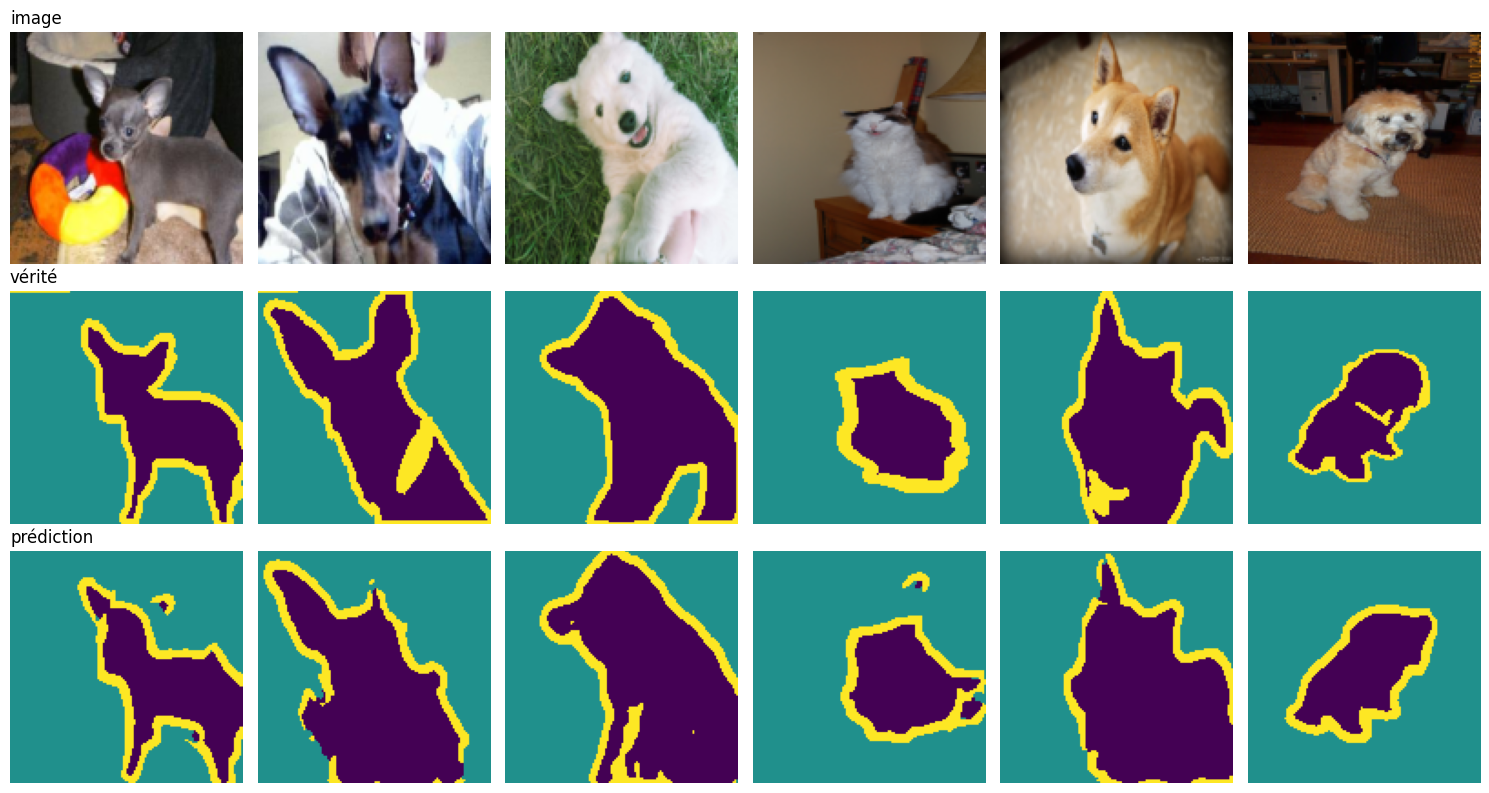

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MiniUNet(in_channels=3, n_classes=3).to(device)
model.load_state_dict(torch.load("../../models/unet_best.pt", map_location=device))
model.eval()

_, val_loader, _ = charger_donnees(batch_size=8)
images, masques = next(iter(val_loader))
with torch.no_grad():
    pred = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for k in range(6):
    axes[0, k].imshow(denormaliser(images[k]).permute(1, 2, 0))
    axes[1, k].imshow(masques[k], vmin=0, vmax=2)
    axes[2, k].imshow(pred[k], vmin=0, vmax=2)
    for ligne in range(3):
        axes[ligne, k].axis("off")
axes[0, 0].set_title("image", loc="left")
axes[1, 0].set_title("vérité", loc="left")
axes[2, 0].set_title("prédiction", loc="left")
plt.tight_layout(); plt.show()

Pareil pour le modèle sans skip connections. Regarde surtout les contours des animaux et la classe « bordure ».

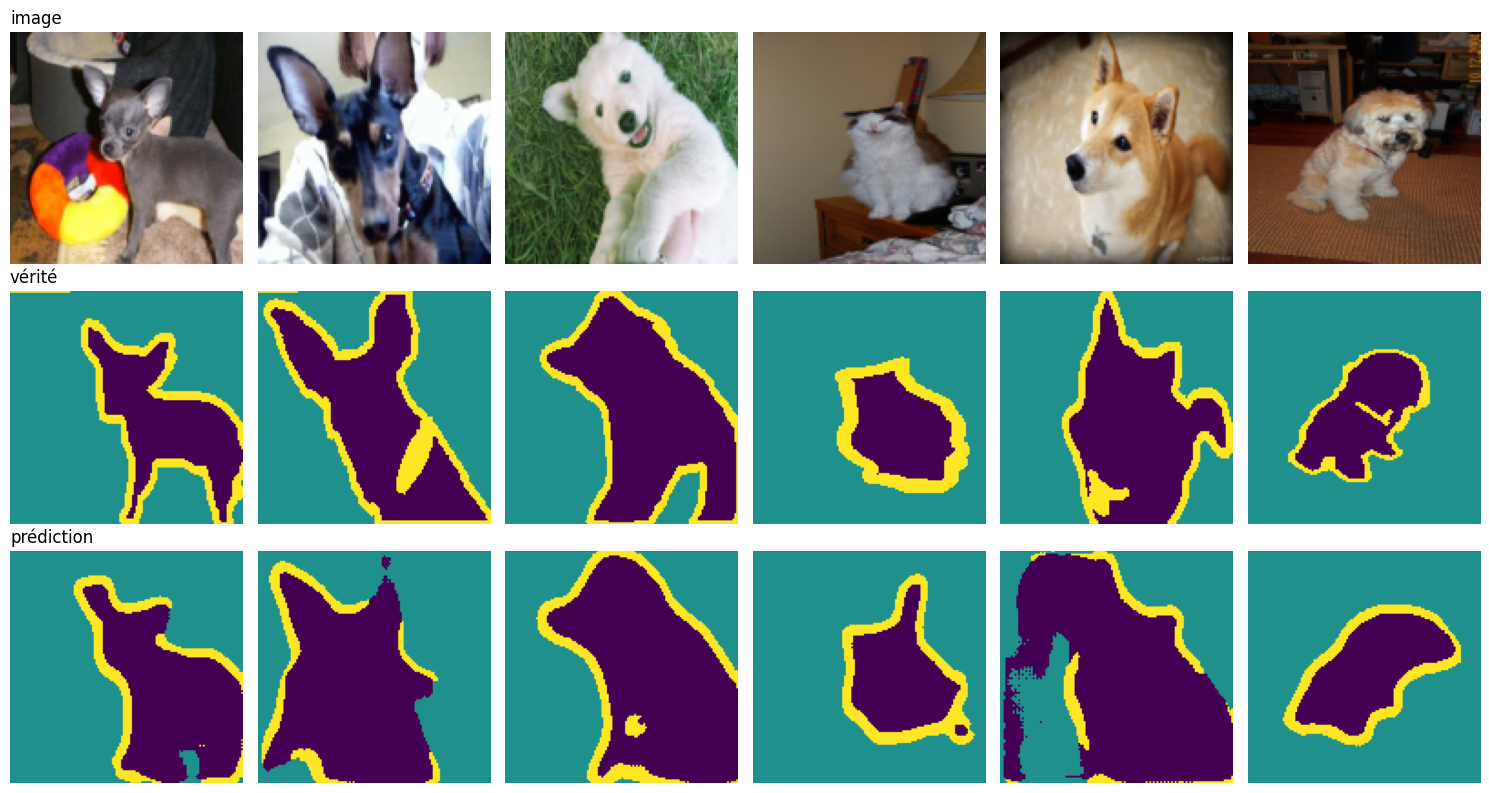

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MiniUNet(in_channels=3, n_classes=3 , skip=False).to(device)
model.load_state_dict(torch.load("../../models/unet_best_sans_skip.pt", map_location=device))
model.eval()

_, val_loader, _ = charger_donnees(batch_size=8)
images, masques = next(iter(val_loader))
with torch.no_grad():
    pred = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for k in range(6):
    axes[0, k].imshow(denormaliser(images[k]).permute(1, 2, 0))
    axes[1, k].imshow(masques[k], vmin=0, vmax=2)
    axes[2, k].imshow(pred[k], vmin=0, vmax=2)
    for ligne in range(3):
        axes[ligne, k].axis("off")
axes[0, 0].set_title("image", loc="left")
axes[1, 0].set_title("vérité", loc="left")
axes[2, 0].set_title("prédiction", loc="left")
plt.tight_layout(); plt.show()

On redéfinit `evaluate` ici pour pouvoir lancer la dernière cellule sans relancer l'entraînement.

In [10]:
@torch.no_grad()                     
def evaluate(model, loader, critere, device, n_classes=3):
    model.eval()                      
    total, n = 0.0, 0
    intersection = torch.zeros(n_classes)
    union = torch.zeros(n_classes)
    for images, masques in loader:
        images, masques = images.to(device), masques.to(device)
        logits = model(images)
        total += critere(logits, masques).item() * images.size(0)
        n += images.size(0)
        pred = logits.argmax(dim=1)

        for c in range(n_classes):
          
            mask_pred = pred == c
            mask_true = masques == c
            
            intersection[c] += (mask_true & mask_pred).sum().item()
            union[c] += (mask_pred | mask_true).sum().item()

    iou = intersection / union.clamp(min=1)    
    return total / n, iou

## 7. Comparaison finale sur le test

Les deux modèles sont évalués sur les images de test, qu'ils n'ont jamais vues pendant l'entraînement.

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

_, _, test_loader = charger_donnees(batch_size=16)
critere = nn.CrossEntropyLoss()

for nom, fichier, skip in [("avec skips", "../../models/unet_best.pt", True),
                           ("sans skips", "../../models/unet_best_sans_skip.pt", False)]:
    model = MiniUNet(in_channels=3, n_classes=3, skip=skip).to(device)
    model.load_state_dict(torch.load(fichier, map_location=device))
    loss, iou = evaluate(model, test_loader, critere, device)
    details = "  ".join(f"{c} {v:.3f}" for c, v in zip(CLASSES, iou.tolist()))
    print(f"{nom:11s} | {details} | mIoU {iou.mean():.3f}")

avec skips  | animal 0.798  fond 0.888  bordure 0.471 | mIoU 0.719
sans skips  | animal 0.767  fond 0.874  bordure 0.375 | mIoU 0.672


## À retenir

- U-Net descend pour comprendre l'image, puis remonte pour retrouver la position de chaque pixel.
- Les skip connections ramènent les détails perdus en descendant. Sans elles, le réseau sait à peu près où est l'animal, mais les contours sont flous.
- Avant un long entraînement, on vérifie que le réseau arrive à apprendre un seul batch par cœur.
- Pour la segmentation, on mesure avec l'IoU, pas avec la précision.

## Exercices

1. Dans les résultats, quelle classe a la plus mauvaise IoU ? Pourquoi, à ton avis ?
2. Change `base=32` en `base=16`. Combien de paramètres reste-t-il ? Le résultat est-il beaucoup moins bon ?
3. Enlève seulement la skip connection du haut (`up4`) et garde les autres. Qu'est-ce que ça change ?